# 03 ML Pipeline: Customer Tribe Discovery

This notebook starts from the prepared parquet outputs created by Notebook 02. It does not repeat raw loading, cleaning, or exploratory data quality work from Notebooks 01 and 02.

The goal is to discover product-first customer tribes from purchase behavior. The client hypothesis is roughly 10-15 tribes, but that range is not used as a modeling constraint. The final recommendation is selected from metrics, stability-ready diagnostics, cluster balance, product/sector lift interpretability, and business usefulness.

## Experiment Workbench

Optional hyperparameter experiments now live in `04_experiment_sandbox.ipynb`. Use that notebook to test variants, promote the winning settings into YAML, then rerun this official pipeline notebook to produce clean artifacts.


## Stage 0: Load Prepared Data

Notebook 03 consumes `df_combined.parquet`, validates the fields required for ML, and merges product metadata only if the prepared file does not already contain it.

Run mode: dev
Data path: C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\data\dev
Model path: C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\models
Output path: C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev
[08:27:05] Stage 0 figures: wrote prepared data overview | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\stage0_prepared_data_overview.png


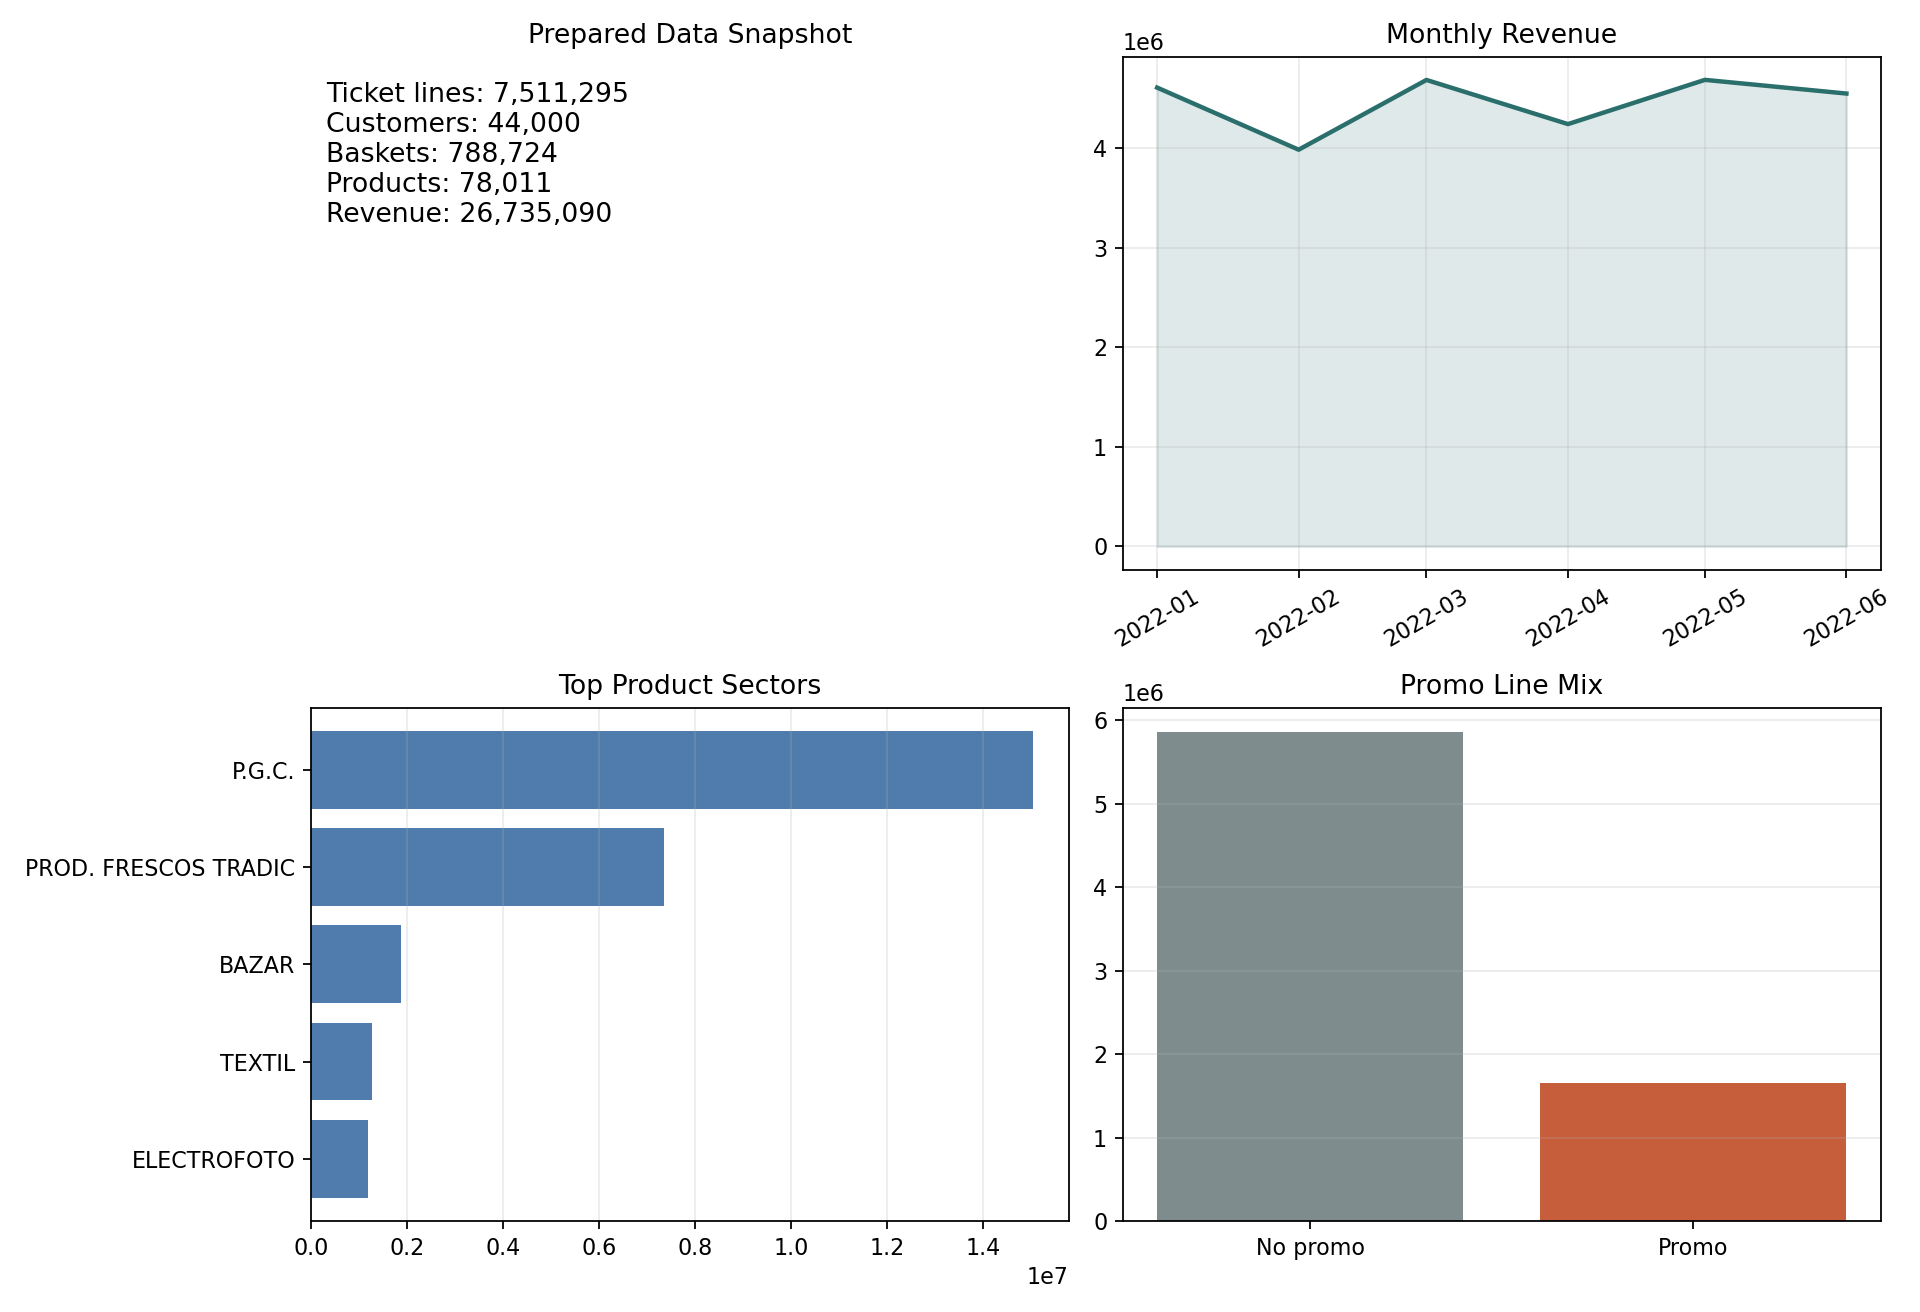

In [2]:
import os

# Mode toggle: this cell is authoritative, even if src.config was imported earlier in the kernel.
RUN_MODE = "dev"  # change to "prod" for the full production pipeline
os.environ["CARREFOUR_MODE"] = RUN_MODE.strip().lower()

from IPython.display import Image, Markdown, display

from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir():
        project_root = candidate
        break
else:
    project_root = Path.cwd().resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import configure_mode
from src.data_loader import load_prepared_transactions, peek
from src.utils import set_global_seed

previous_mode = globals().get("MODE")
CONFIG = configure_mode(RUN_MODE)
MODE = CONFIG.mode
DATA_PROCESSED = CONFIG.data_processed
MODELS = CONFIG.models
OUTPUTS = CONFIG.outputs

if previous_mode and previous_mode != MODE:
    for stale_name in [
        "transactions",
        "basket_path",
        "item2vec_model",
        "product_embeddings_path",
        "embedding_validation_csv",
        "embedding_validation_md",
        "customer_embeddings_path",
        "behavior_path",
        "feature_sets",
        "model_suite",
        "stage6_diagnostics",
        "profile_paths",
        "comparison_path",
        "selected",
        "selected_assignment_path",
        "selected_profile_path",
    ]:
        globals().pop(stale_name, None)

set_global_seed(CONFIG.random_seed)
CONFIG.ensure_directories()

transactions = load_prepared_transactions(cfg=CONFIG)
print(f"Run mode: {MODE}")
print(f"Data path: {DATA_PROCESSED}")
print(f"Model path: {MODELS}")
print(f"Output path: {OUTPUTS}")
peek(transactions, 3)

from src.visualization import plot_prepared_data_overview

stage0_figure = plot_prepared_data_overview(transactions, cfg=CONFIG)
display(Image(filename=str(stage0_figure)))


## Stage 1: Basket Construction

Each ticket is treated as a basket sentence and each product id is a token. Products are not repeated by quantity unless `baskets.repeat_product_by_quantity` is enabled in the config.

[08:27:05] Stage 1 baskets: cache hit | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\embeddings\basket_sentences.parquet
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\embeddings\basket_sentences.parquet
[08:27:05] Stage 1 figures: wrote basket summary | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\stage1_basket_sentence_lengths.png


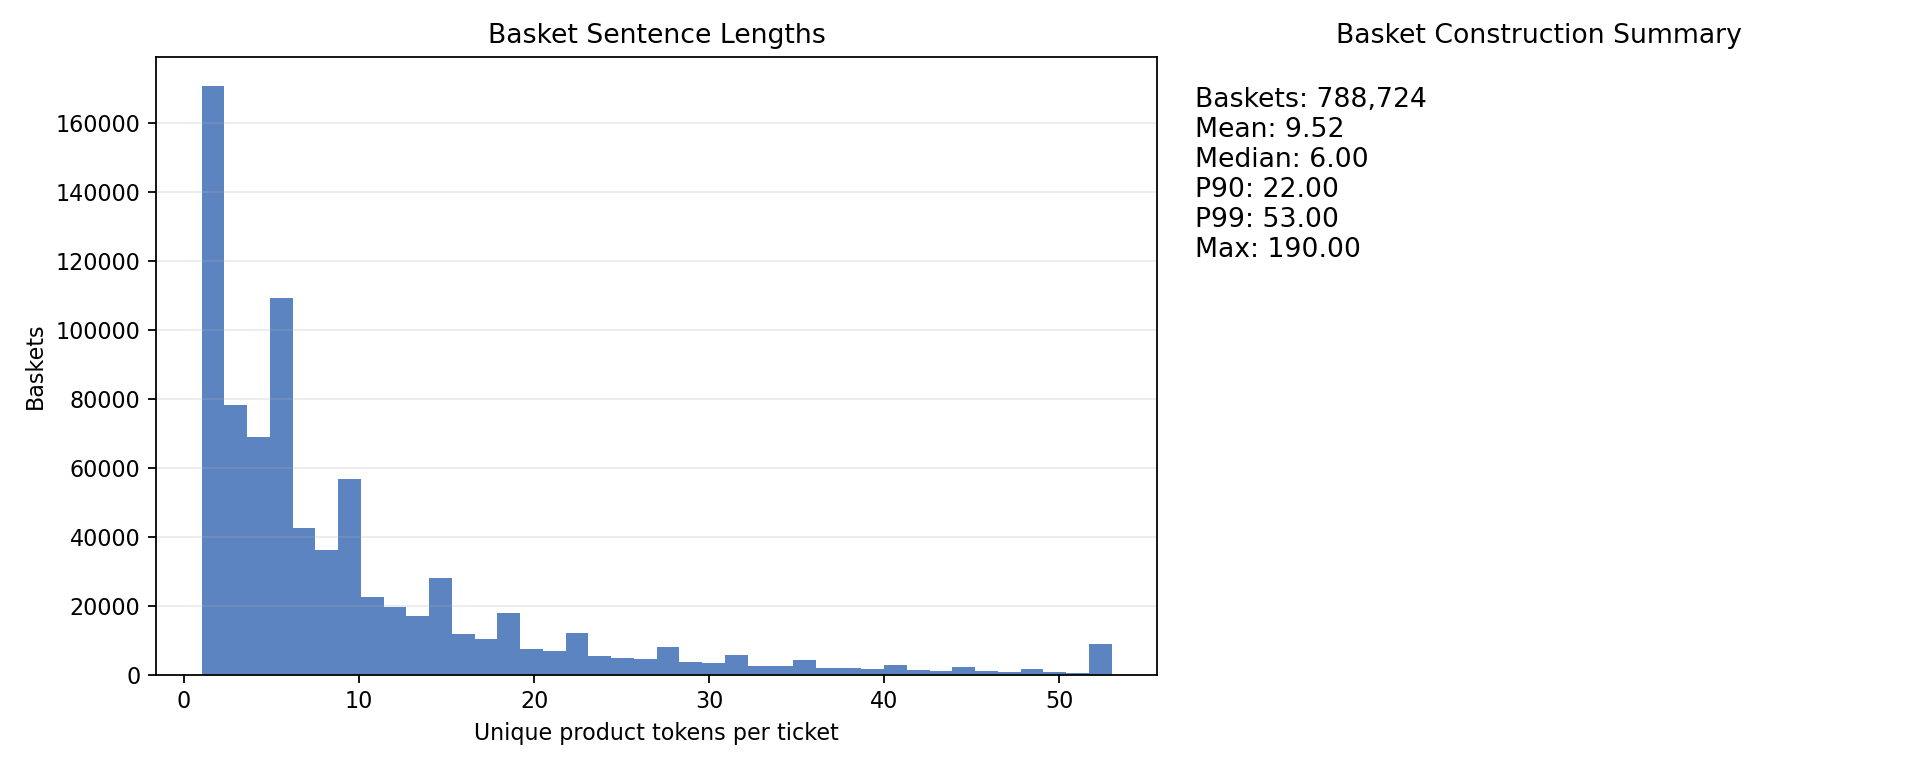

In [3]:
from IPython.display import Image

from src.basket_builder import basket_summary, build_basket_sentences
from src.visualization import plot_basket_summary

basket_path = build_basket_sentences(transactions=transactions, cfg=CONFIG)
print(basket_path)
basket_summary(basket_path)
stage1_figure = plot_basket_summary(basket_path, cfg=CONFIG)
display(Image(filename=str(stage1_figure)))


## Stage 2: Item2Vec Product Embeddings

The Word2Vec model learns product proximity from basket co-occurrence. These product embeddings are the core signal used to represent customers.

The training function prints the active hyperparameters and one progress line per epoch. If a cached model already exists, it prints the cache details instead; pass `force=True` to retrain.

Item2Vec: loading cached model
  baskets: 788,724
  product tokens: 7,511,295; avg/basket: 9.52; median/basket: 6.00
  model path: C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\models\word2vec_product.model
  config: vector_size=100, window=190 (configured=5, full_basket_context=True), min_count=10, negative=10, sample=0.0005, epochs=3, sg=1, workers=1, seed=42
Item2Vec cache loaded: vocab=37,299, vector_size=100
[08:27:09] Stage 2 product embeddings: cache hit | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\embeddings\product_embeddings.parquet
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\embeddings\product_embeddings.parquet
[08:27:10] Stage 2 figures: wrote product embedding diagnostics | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\stage2_product_embedding_diagnostics.png


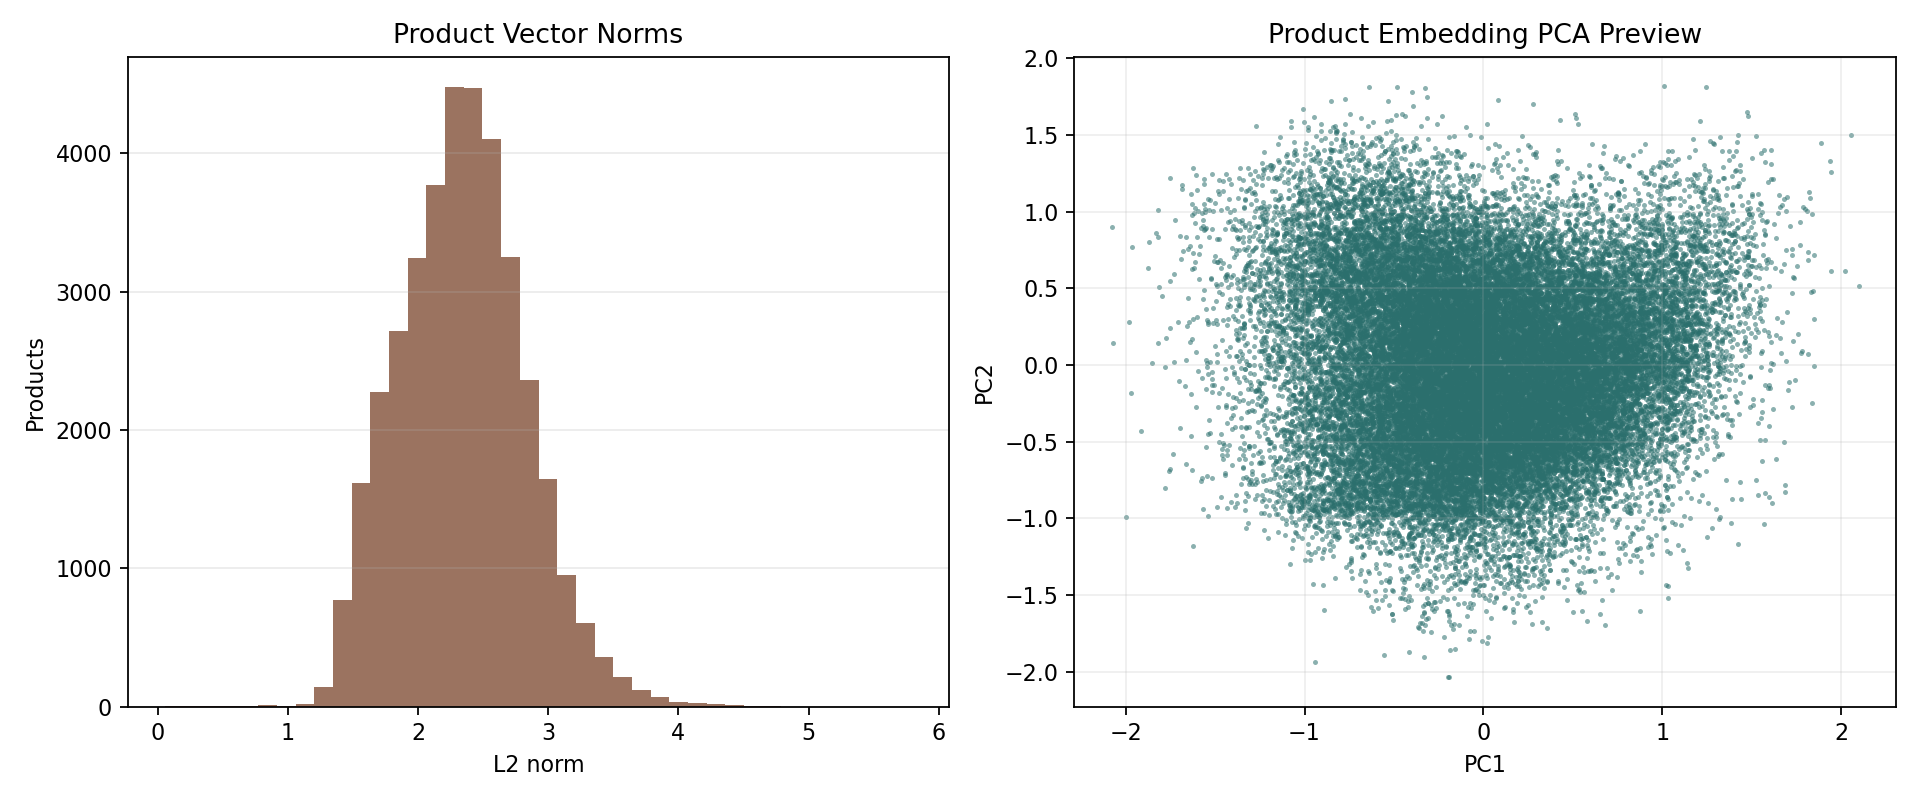

In [4]:
from IPython.display import Image

from src.item2vec import save_product_embeddings, train_item2vec
from src.visualization import plot_product_embedding_diagnostics

item2vec_model = train_item2vec(basket_path, cfg=CONFIG, verbose=True)
product_embeddings_path = save_product_embeddings(item2vec_model, cfg=CONFIG)
print(product_embeddings_path)
stage2_figure = plot_product_embedding_diagnostics(product_embeddings_path, cfg=CONFIG)
display(Image(filename=str(stage2_figure)))


## Stage 3: Product Embedding Validation

Before clustering customers, the nearest-neighbor report checks whether embeddings capture meaningful substitutes, complements, or shared basket missions.

[08:27:10] Stage 3 embedding validation: building nearest-neighbor report | output=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\embedding_validation.md
[08:27:11] Stage 3 embedding validation: wrote reports | sampled_products=25, csv=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\embedding_validation.csv
[08:27:11] Stage 3 embedding validation: finished | elapsed_s=0.9000
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\embedding_validation.csv
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\embedding_validation.md
[08:27:11] Stage 3 figures: wrote embedding validation summary | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\stage3_embedding_validation_summary.png


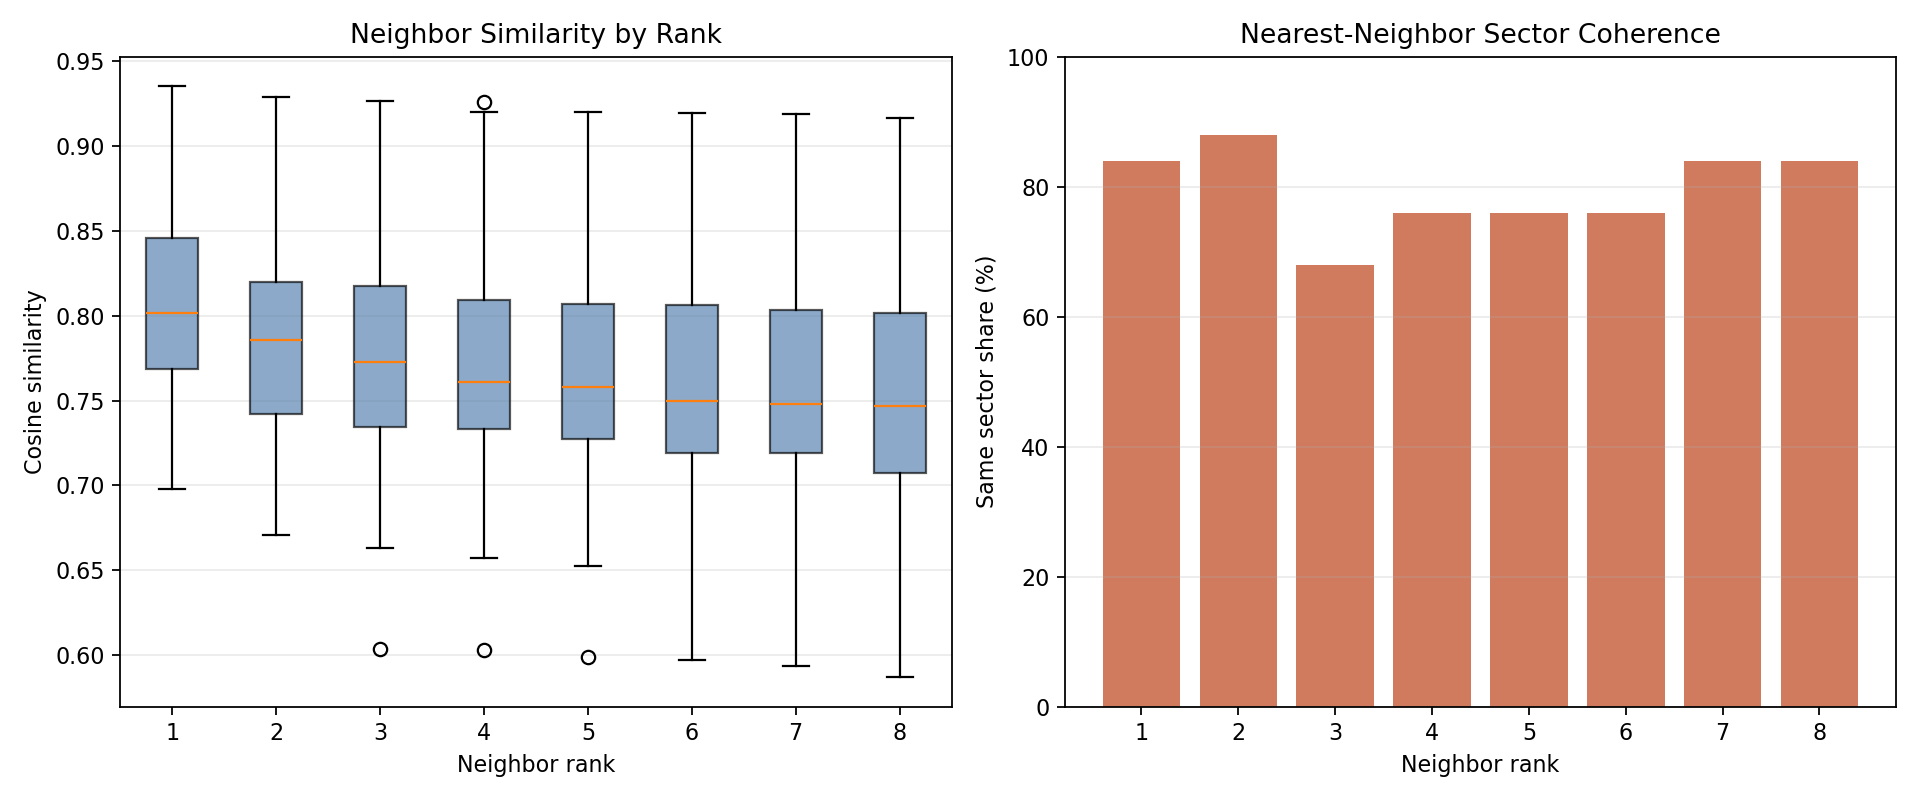

In [5]:
from IPython.display import Image

from src.embedding_validation import validate_product_embeddings
from src.visualization import plot_embedding_validation_summary

embedding_validation_csv, embedding_validation_md = validate_product_embeddings(
    product_embeddings_path,
    transactions=transactions,
    cfg=CONFIG,
)
print(embedding_validation_csv)
print(embedding_validation_md)
stage3_figure = plot_embedding_validation_summary(embedding_validation_csv, cfg=CONFIG)
display(Image(filename=str(stage3_figure)))


## Stage 4: Customer Embeddings

Customer vectors are weighted means of product embeddings. The official weighting uses product quantities (`unidades`) only, so clustering is driven by products and purchase intensity rather than spend. IDF-downweighted variants are tested only in the experiment sandbox before any promotion to YAML.

[08:27:12] Stage 4 customer embeddings: aggregating product vectors | output=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\customer_embeddings.parquet, weight_strategy=quantity, normalize_vectors=True
[08:27:17] Stage 4 customer embeddings: wrote artifact | customers=43998, path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\customer_embeddings.parquet
[08:27:17] Stage 4 customer embeddings: finished | elapsed_s=5.9000
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\customer_embeddings.parquet
[08:27:18] Stage 4 figures: wrote customer embedding diagnostics | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\stage4_customer_embedding_diagnostics.png


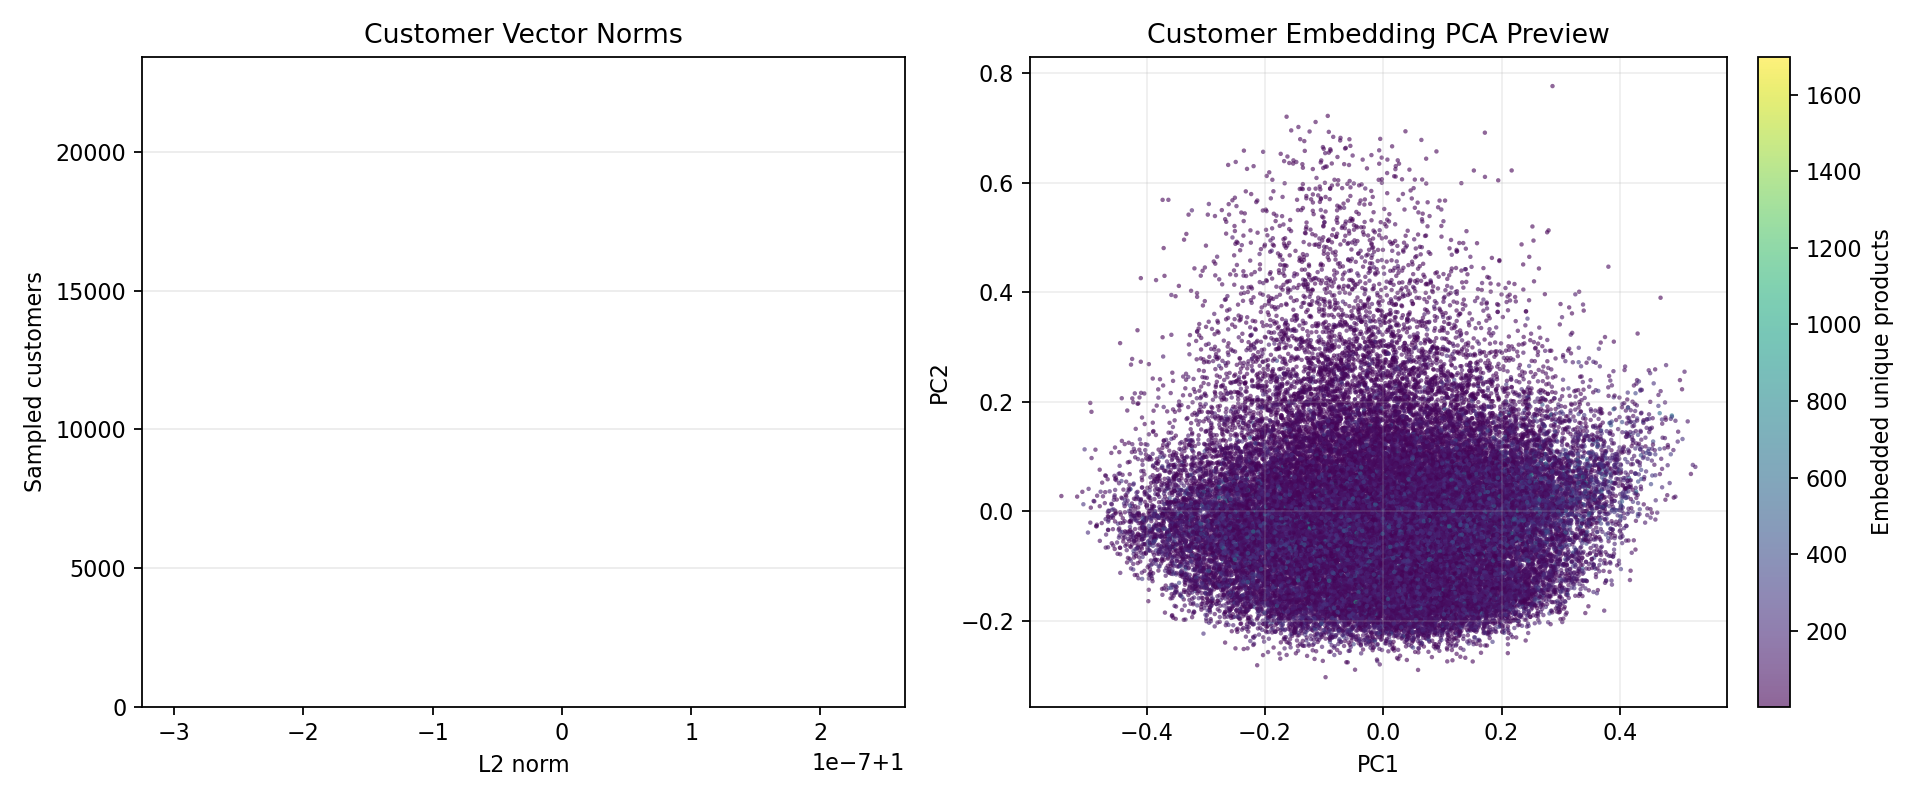

In [6]:
from IPython.display import Image

from src.customer_embeddings import build_customer_embeddings
from src.visualization import plot_customer_embedding_diagnostics

customer_embeddings_path = build_customer_embeddings(
    product_embeddings_path,
    transactions=transactions,
    normalize_vectors=CONFIG.get("customer_embeddings.normalize_vectors", False),
    cfg=CONFIG,
)
print(customer_embeddings_path)
stage4_figure = plot_customer_embedding_diagnostics(customer_embeddings_path, cfg=CONFIG)
display(Image(filename=str(stage4_figure)))


In [13]:
import numpy as np, polars as pl
ce = pl.read_parquet(customer_embeddings_path)
emb = [c for c in ce.columns if c.startswith("emb_")]
norms = np.linalg.norm(ce.select(emb).to_numpy(), axis=1)
print(f"norm min/mean/max: {norms.min():.3f} / {norms.mean():.3f} / {norms.max():.3f}")

norm min/mean/max: 1.000 / 1.000 / 1.000


## Stage 5: Behavioral Features

Behavioral features are stored separately so the analysis can compare embeddings-only segmentation against embeddings plus behavior without allowing KPIs to silently dominate the product signal.

[08:36:05] Stage 5 behavior: cache hit | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\customer_behavior_features.parquet
[08:36:05] Stage 5 feature set: cache hit | variant=embeddings_only, path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\feature_set_embeddings_only.parquet


[08:36:05] Stage 5 feature set: cache hit | variant=embeddings_behavior, path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\feature_set_embeddings_behavior.parquet
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\customer_behavior_features.parquet
{'embeddings_only': WindowsPath('C:/Users/vivim/OneDrive/Documentos/Capstone/carrefour_capstone/outputs/dev/features/feature_set_embeddings_only.parquet'), 'embeddings_behavior': WindowsPath('C:/Users/vivim/OneDrive/Documentos/Capstone/carrefour_capstone/outputs/dev/features/feature_set_embeddings_behavior.parquet')}
[08:36:05] Stage 5 figures: wrote behavioral feature summary | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\stage5_behavioral_feature_summary.png
[08:36:06] Stage 5 figures: wrote feature-set summary | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\stage5_feature_set_summary.

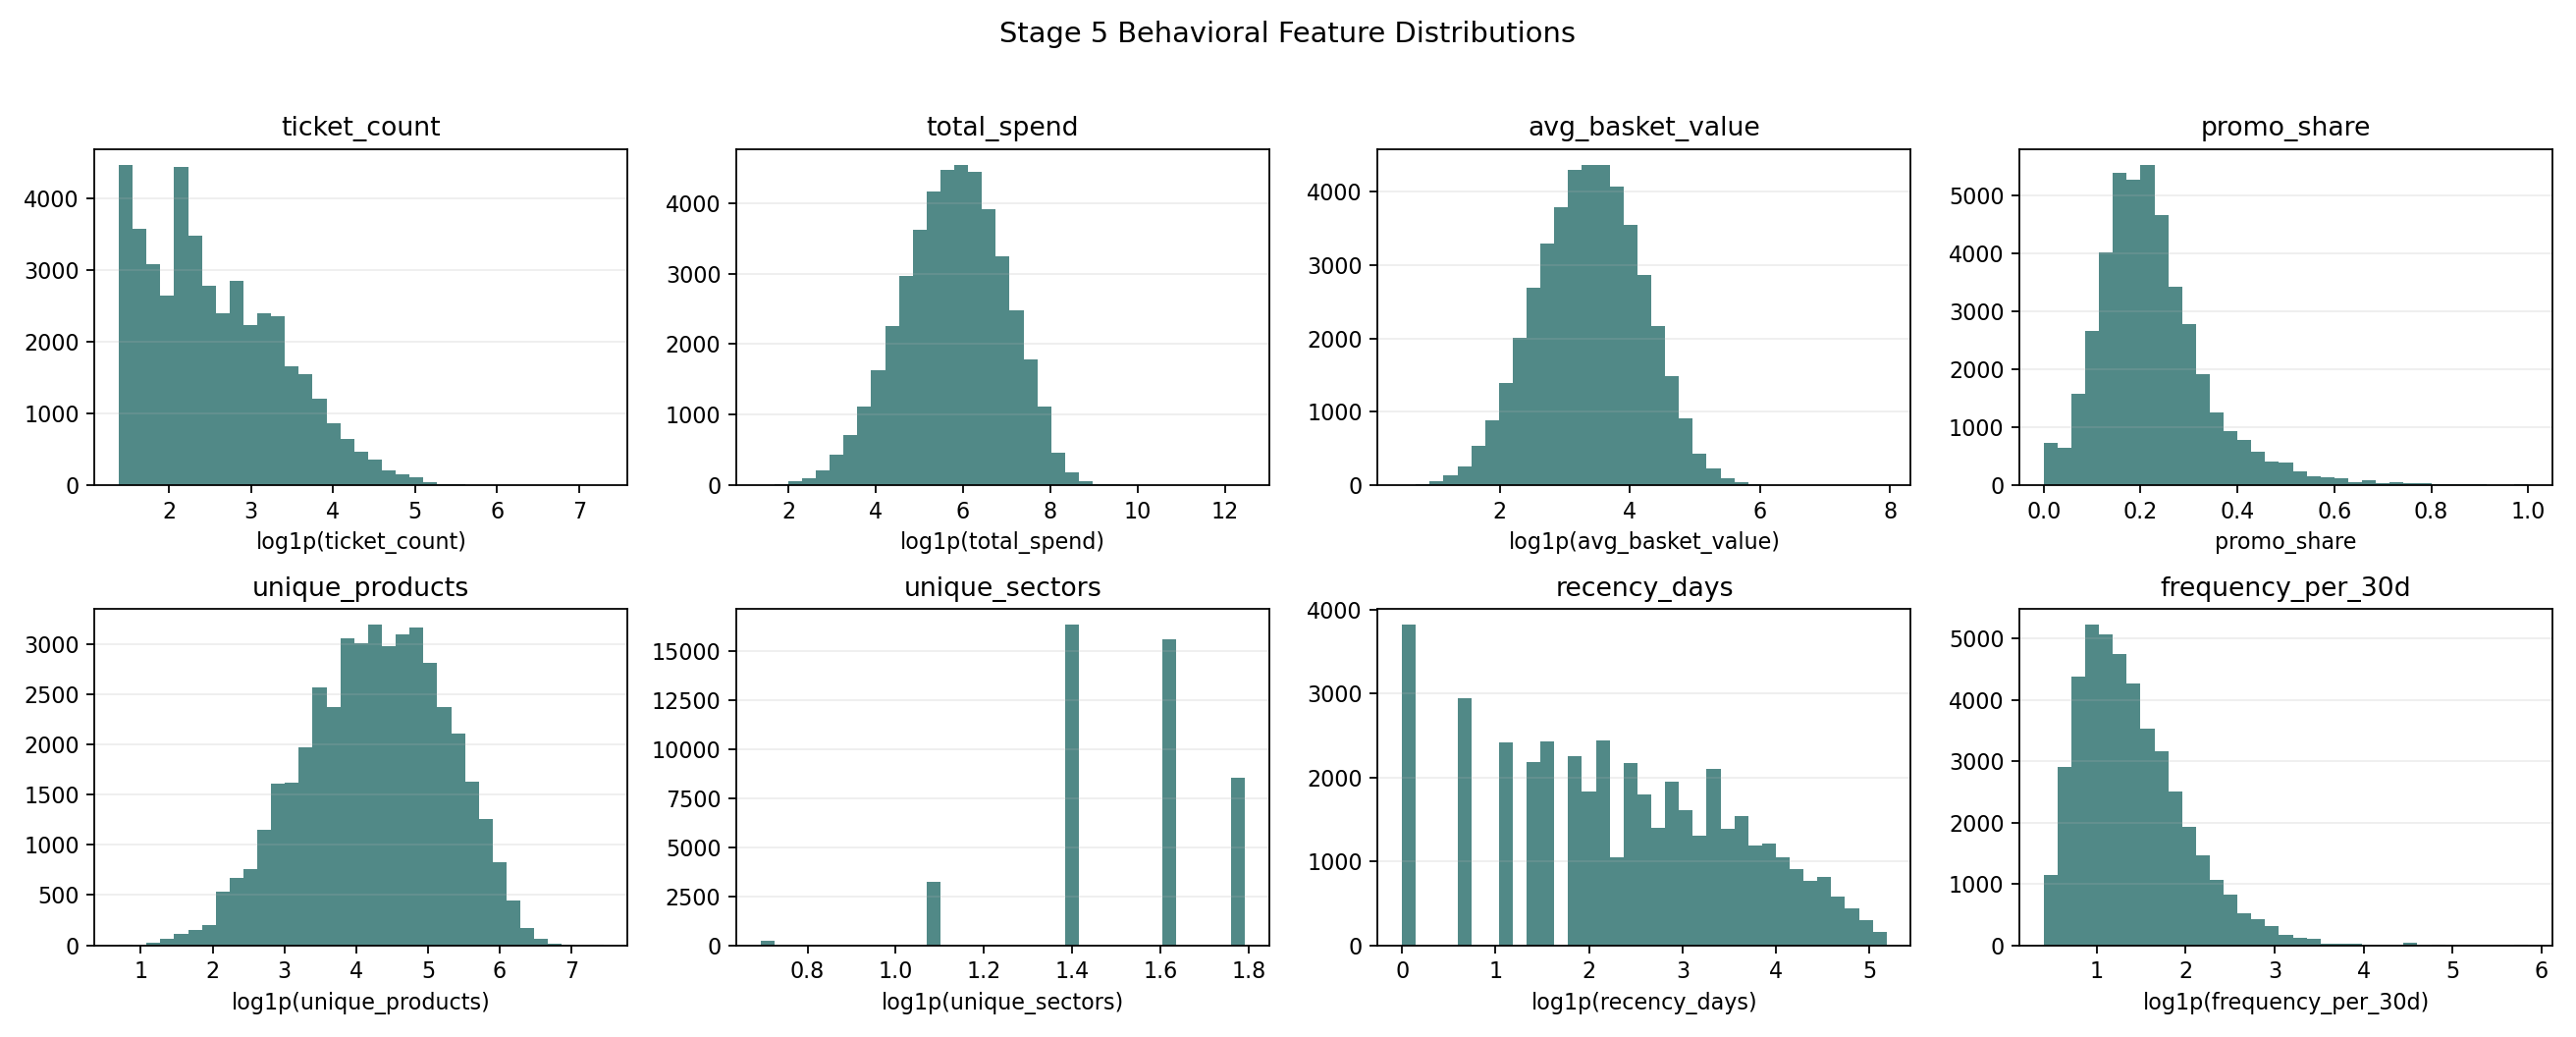

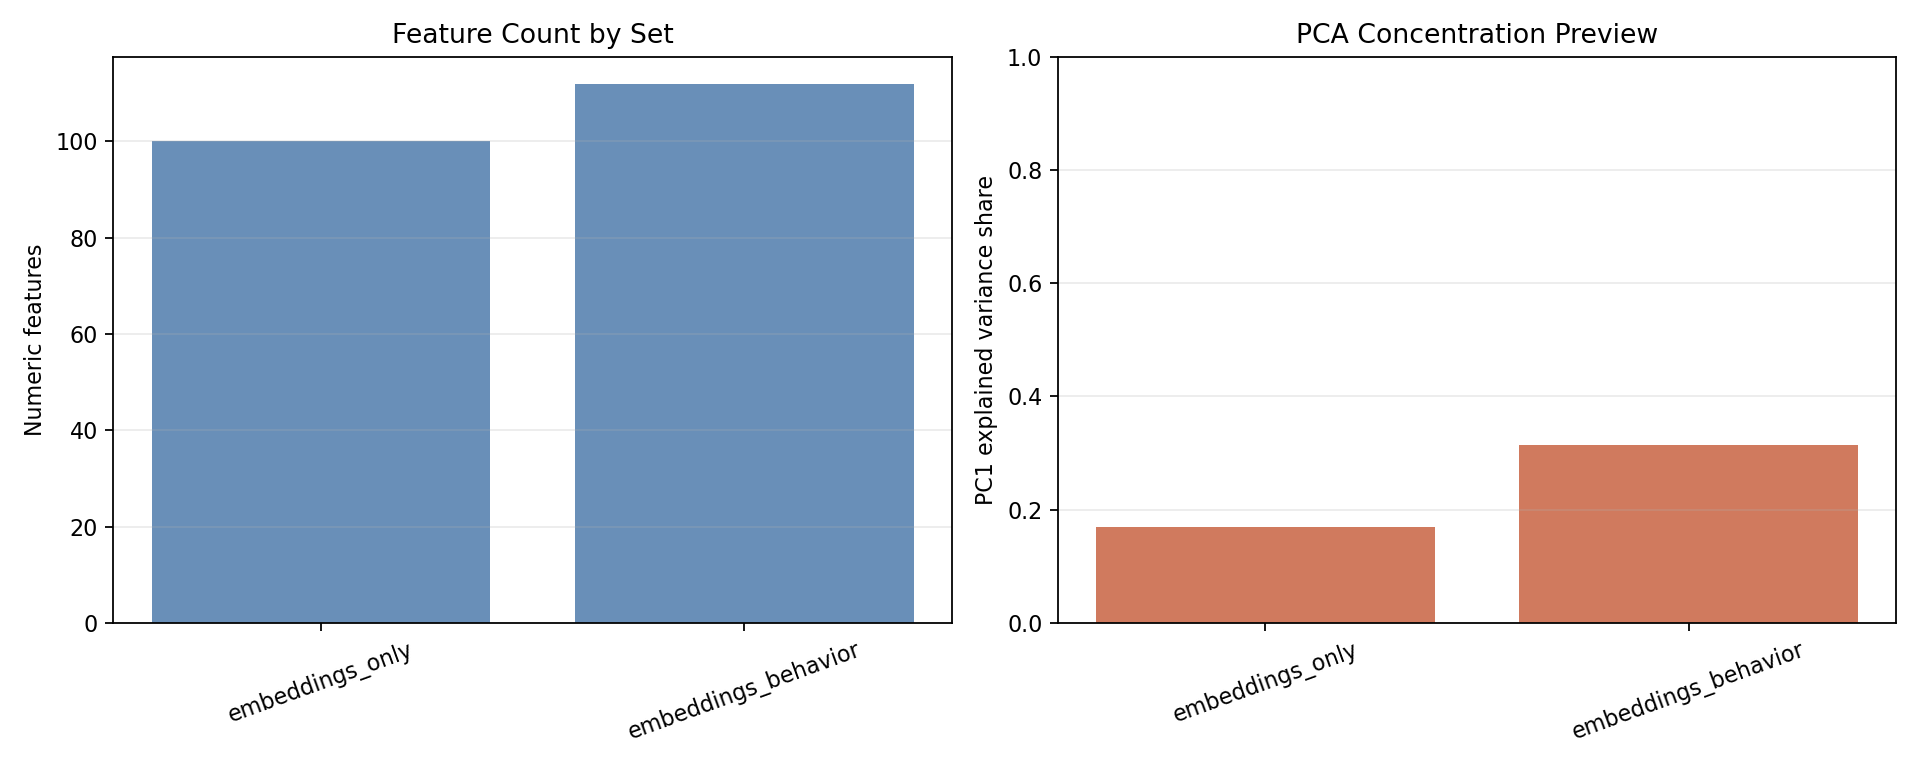

In [14]:
from IPython.display import Image

from src.feature_engineering import build_behavioral_features, build_feature_set
from src.visualization import plot_behavioral_feature_summary, plot_feature_set_summary

behavior_path = build_behavioral_features(transactions=transactions, cfg=CONFIG)
feature_set_a = build_feature_set(customer_embeddings_path, variant="embeddings_only", cfg=CONFIG)
feature_set_b = build_feature_set(
    customer_embeddings_path,
    behavior_path=behavior_path,
    variant="embeddings_behavior",
    cfg=CONFIG,
)
feature_sets = {
    "embeddings_only": feature_set_a,
    "embeddings_behavior": feature_set_b,
}
print(behavior_path)
print(feature_sets)
stage5_behavior_figure = plot_behavioral_feature_summary(behavior_path, cfg=CONFIG)
stage5_feature_set_figure = plot_feature_set_summary(feature_sets, cfg=CONFIG)
display(Image(filename=str(stage5_behavior_figure)))
display(Image(filename=str(stage5_feature_set_figure)))


## Stage 6: Candidate Model Comparison

The official pipeline compares algorithm families without forcing a target tribe count. Broader hyperparameter sweeps belong in `04_experiment_sandbox.ipynb`; promote only evidence-backed settings into YAML before running this notebook.

- `model_a_gmm`: Raw customer embeddings to Gaussian Mixture Model, searched across the configured `gmm.components_min` to `gmm.components_max` range.
- `model_b_umap_hdbscan`: UMAP customer manifold to HDBSCAN using the active YAML `umap` and `hdbscan` settings.
- `model_c_pca_kmeans`: PCA representation to MiniBatchKMeans, searched across the configured `kmeans.k_min` to `kmeans.k_max` range.

UMAP is treated as a candidate clustering representation, not as an automatic winner. Its value must be proven by metrics, stability, and product-lift interpretability.

[08:36:15] Stage 6 model suite: running candidate model suite | feature_path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\feature_set_embeddings_only.parquet
[08:36:15] Stage 6 model suite: starting Model A GMM search | components=6-25
[08:36:15] Stage 6 GMM: cache hit | model=model_a_gmm, results=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\models\model_selection\model_a_gmm_grid_results.parquet
[08:36:15] Stage 6 model suite: raw HDBSCAN diagnostic disabled
[08:36:15] Stage 6 model suite: starting Model B UMAP-HDBSCAN representation
[08:36:15] Stage 6 UMAP: cache hit | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\feature_set_umap_cluster.parquet
[08:36:15] Stage 6 model suite: starting Model B UMAP-HDBSCAN clustering
[08:36:15] Stage 6 HDBSCAN: cache hit | results=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\models\model_selection\model_b_umap


### Stage 6 Diagnostics

- Diagnostics parquet: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\stage6_candidate_model_diagnostics.parquet`
- Diagnostics summary CSV: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\stage6_candidate_model_summary.csv`
- Diagnostics summary Markdown: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\stage6_candidate_model_summary.md`
- Diagnostics figure: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\stage6_candidate_model_diagnostics.png`


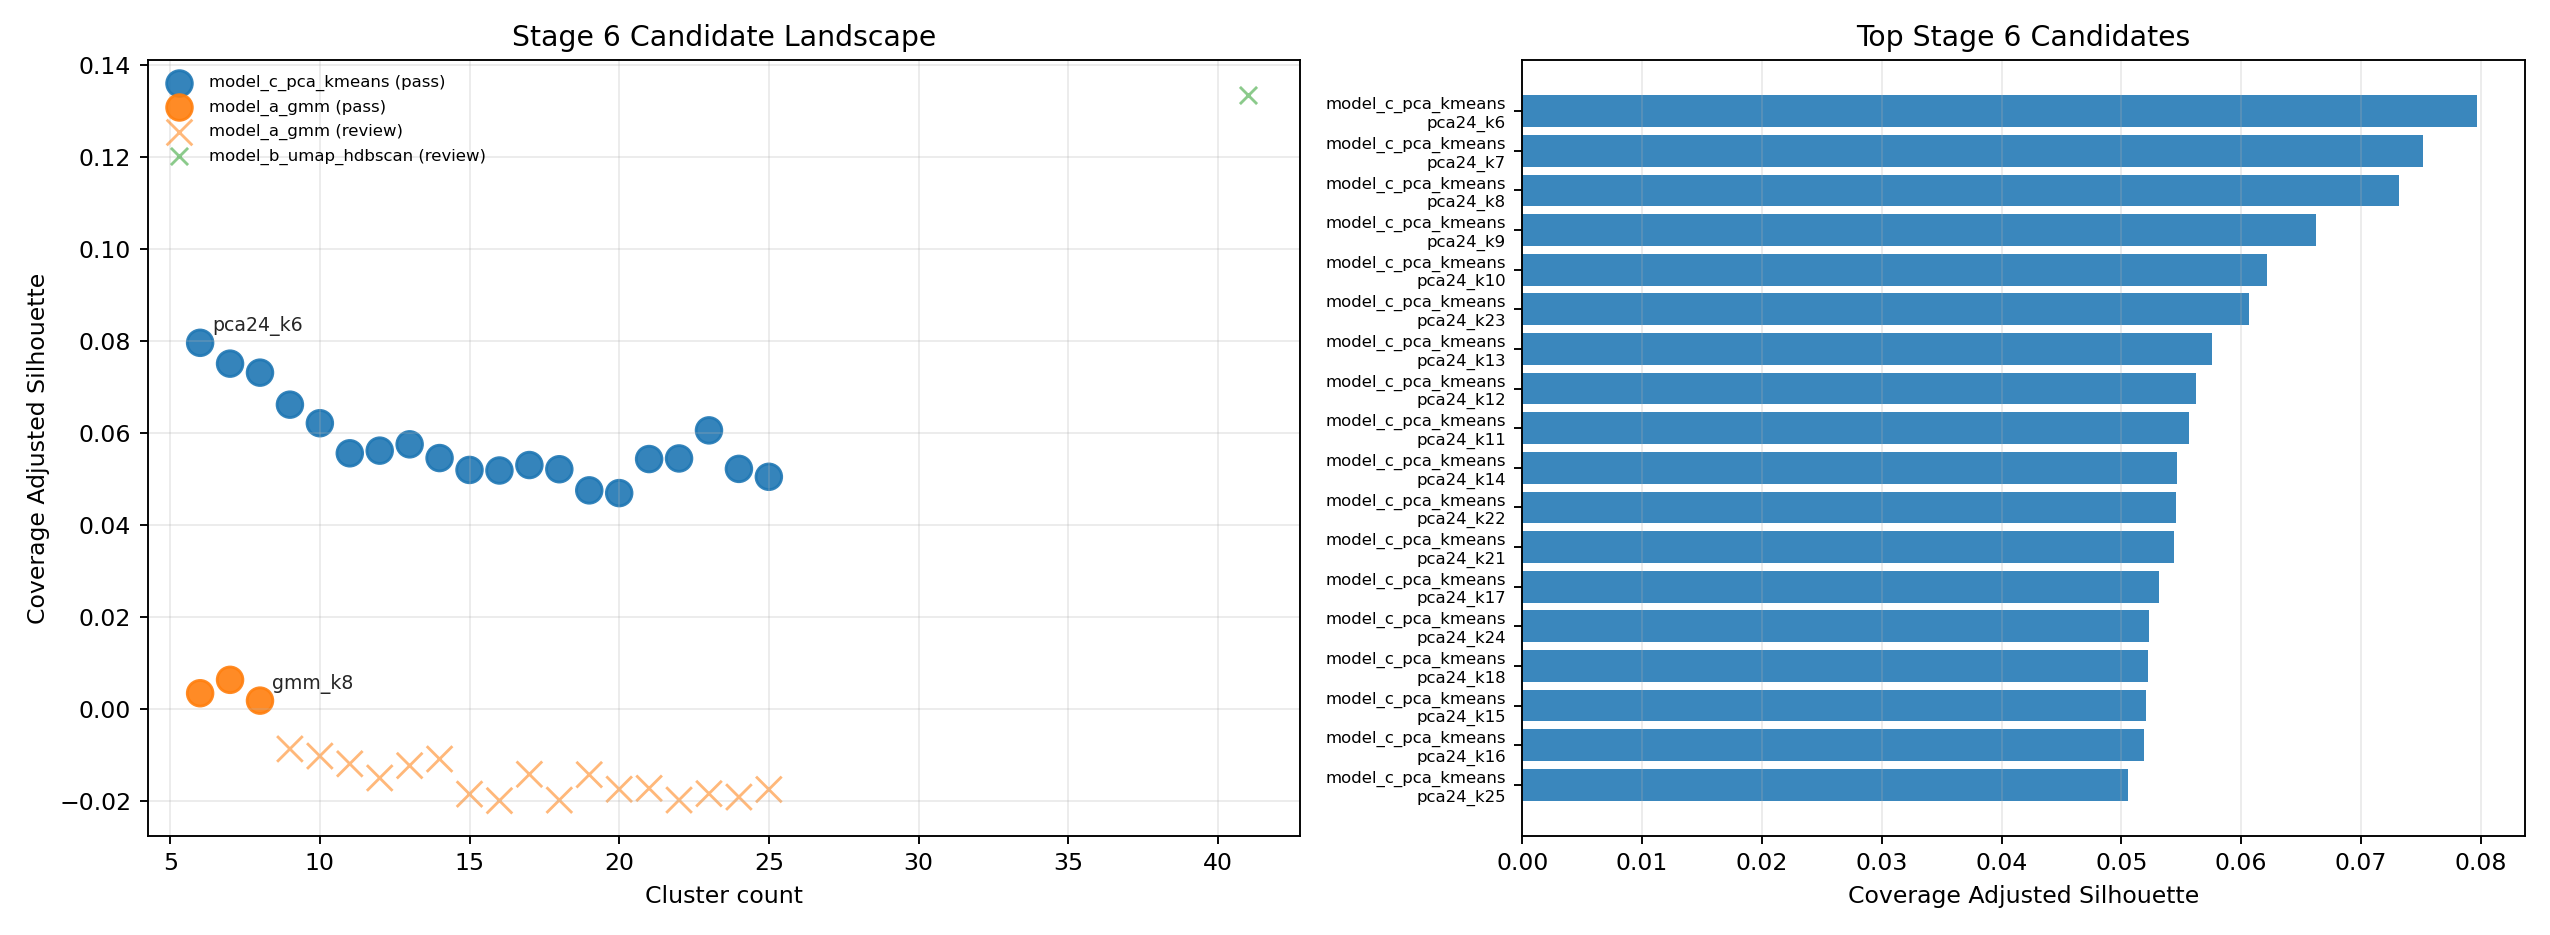

stage6_rank,model_name,algorithm_name,model_variant,cluster_count,coverage_adjusted_silhouette,silhouette,davies_bouldin,noise_pct,passes_quality_gate
i64,str,str,str,i64,f64,f64,f64,f64,bool
1,"""model_c_pca_kmeans""","""PCA_MiniBatchKMeans""","""pca24_k6""",6,0.079673,0.079673,2.340485,0.0,true
2,"""model_c_pca_kmeans""","""PCA_MiniBatchKMeans""","""pca24_k7""",7,0.075145,0.075145,2.385735,0.0,true
3,"""model_c_pca_kmeans""","""PCA_MiniBatchKMeans""","""pca24_k8""",8,0.073188,0.073188,2.491665,0.0,true
4,"""model_c_pca_kmeans""","""PCA_MiniBatchKMeans""","""pca24_k9""",9,0.06623,0.06623,2.493827,0.0,true
5,"""model_c_pca_kmeans""","""PCA_MiniBatchKMeans""","""pca24_k10""",10,0.062198,0.062198,2.518241,0.0,true
…,…,…,…,…,…,…,…,…,…
21,"""model_a_gmm""","""GaussianMixture""","""gmm_k7""",7,0.006423,0.006423,4.054987,0.0,true
22,"""model_a_gmm""","""GaussianMixture""","""gmm_k6""",6,0.003508,0.003508,4.279785,0.0,true
23,"""model_a_gmm""","""GaussianMixture""","""gmm_k8""",8,0.001902,0.001902,3.705371,0.0,true


In [15]:
import polars as pl
from IPython.display import Image, Markdown, display

from src.model_selection import build_candidate_model_diagnostics, run_candidate_model_suite
from src.visualization import plot_stage6_model_diagnostics

if "feature_sets" not in globals():
    feature_set_outputs = CONFIG.get("feature_sets.outputs", {})
    feature_sets = {
        name: CONFIG.outputs / "features" / filename
        for name, filename in feature_set_outputs.items()
    }
    missing_feature_sets = [path for path in feature_sets.values() if not path.exists()]
    if missing_feature_sets:
        raise FileNotFoundError(
            "Stage 6 needs the Stage 5 feature-set parquet files. "
            f"Missing: {missing_feature_sets}. Run Stage 5 first."
        )

selection_feature_set = CONFIG.get("modeling.feature_set_for_selection", "embeddings_only")
model_suite = run_candidate_model_suite(feature_sets[selection_feature_set], cfg=CONFIG)
stage6_diagnostics = build_candidate_model_diagnostics(model_suite, cfg=CONFIG)
stage6_figure = plot_stage6_model_diagnostics(stage6_diagnostics["parquet"], cfg=CONFIG)

display(Markdown(f"""
### Stage 6 Diagnostics

- Diagnostics parquet: `{stage6_diagnostics['parquet']}`
- Diagnostics summary CSV: `{stage6_diagnostics['summary_csv']}`
- Diagnostics summary Markdown: `{stage6_diagnostics['summary_md']}`
- Diagnostics figure: `{stage6_figure}`
"""))
display(Image(filename=str(stage6_figure)))

pl.read_parquet(stage6_diagnostics["parquet"]).select([
    "stage6_rank",
    "model_name",
    "algorithm_name",
    "model_variant",
    "cluster_count",
    "coverage_adjusted_silhouette",
    "silhouette",
    "davies_bouldin",
    "noise_pct",
    "passes_quality_gate",
]).head(25)

## Stage 7: Cluster Validity and Stability

This section is a guardrail before interpretation. It reviews cluster count, noise, balance, and a lightweight perturbation check that asks whether labels remain recoverable from the original customer-product feature geometry. This does not replace a full repeated-seed stability study, but it makes instability visible before tribe profiles are interpreted.

In [16]:
from src.cluster_validation import build_cluster_validity_stability_report

cluster_validity = build_cluster_validity_stability_report(
    model_suite,
    feature_sets[selection_feature_set],
    cfg=CONFIG,
)

display(Markdown(f"""
### Cluster Validity and Stability

- Validity/stability parquet: `{cluster_validity['parquet']}`
- Validity/stability summary CSV: `{cluster_validity['summary_csv']}`
- Validity/stability summary Markdown: `{cluster_validity['summary_md']}`
"""))

pl.read_parquet(cluster_validity["parquet"]).select([
    "candidate_id",
    "cluster_count",
    "noise_pct",
    "cluster_size_cv",
    "jitter_ari_mean",
    "jitter_ari_std",
    "jitter_label_recovery_accuracy_mean",
    "validity_note",
])

[08:36:24] Cluster validity: building validity and stability report | feature_path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\features\feature_set_embeddings_only.parquet, repeats=5
[08:36:26] Cluster validity: finished | elapsed_s=1.5000
[08:36:26] Experiment summary: wrote human-readable summaries | rows=3, csv=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\cluster_validity_stability_summary.csv, markdown=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\cluster_validity_stability_summary.md
[08:36:26] Cluster validity: wrote validity and stability report | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\cluster_validity_stability.parquet



### Cluster Validity and Stability

- Validity/stability parquet: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\cluster_validity_stability.parquet`
- Validity/stability summary CSV: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\cluster_validity_stability_summary.csv`
- Validity/stability summary Markdown: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_selection\cluster_validity_stability_summary.md`


candidate_id,cluster_count,noise_pct,cluster_size_cv,jitter_ari_mean,jitter_ari_std,jitter_label_recovery_accuracy_mean,validity_note
str,i64,f64,f64,f64,f64,f64,str
"""model_a_gmm::gmm_k8""",8,0.0,0.25374,0.641786,0.001565,0.82048,"""Checks internal geometry and p…"
"""model_b_umap_hdbscan::umap_hdb…",41,72.5374,0.617476,0.785277,0.00065,0.8756,"""Checks internal geometry and p…"
"""model_c_pca_kmeans::pca24_k6""",6,0.0,0.313284,0.917086,0.000924,0.9647,"""Checks internal geometry and p…"


## Stage 8: Tribe Profiling and Interpretability

Every candidate solution is profiled using product lift and sector lift. Raw product popularity is not enough because staples tend to dominate all customers.

In [17]:
from src.profiling import profile_tribes

profile_paths = {}
for candidate_key, assignment_path in model_suite["assignment_paths"].items():
    profile_paths[candidate_key] = profile_tribes(
        assignment_path,
        transactions=transactions,
        behavior_path=behavior_path,
        cfg=CONFIG,
    )
profile_paths

[08:36:32] Stage 7 profiling: cache hit | assignments=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\models\model_selection\cluster_assignments_model_a_gmm.parquet, path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\profiles\tribe_profiles_model_a_gmm.parquet
[08:36:32] Stage 7 profiling: cache hit | assignments=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\models\model_selection\cluster_assignments_model_b_umap_hdbscan.parquet, path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\profiles\tribe_profiles_model_b_umap_hdbscan.parquet
[08:36:32] Stage 7 profiling: cache hit | assignments=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\models\model_selection\cluster_assignments_model_c_pca_kmeans.parquet, path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\profiles\tribe_profiles_model_c_pca_kmeans.parquet


{'model_a_gmm::gmm_k8': WindowsPath('C:/Users/vivim/OneDrive/Documentos/Capstone/carrefour_capstone/outputs/dev/profiles/tribe_profiles_model_a_gmm.parquet'),
 'model_b_umap_hdbscan::umap_hdbscan_mcs150_ms1_leaf': WindowsPath('C:/Users/vivim/OneDrive/Documentos/Capstone/carrefour_capstone/outputs/dev/profiles/tribe_profiles_model_b_umap_hdbscan.parquet'),
 'model_c_pca_kmeans::pca24_k6': WindowsPath('C:/Users/vivim/OneDrive/Documentos/Capstone/carrefour_capstone/outputs/dev/profiles/tribe_profiles_model_c_pca_kmeans.parquet')}

## Stage 9: Final Model Selection, Exports, and Figures

The comparison table ranks candidates using empirical metrics, cluster balance, assignment confidence where available, HDBSCAN noise share where relevant, and product/sector lift interpretability.

[08:36:36] Stage 8 exports: building model comparison | candidates=3
[08:36:36] Stage 8 exports: wrote model comparison | selected=pca24_k6, path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_comparison_dev.csv
[08:36:36] Stage 8 exports: finished | elapsed_s=0.0000
[08:36:36] Stage 8 exports: wrote final assignments | rows=43998, path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\customer_tribe_assignments_dev.parquet
[08:36:36] Stage 8 exports: wrote final profiles | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\tribe_profiles_dev.csv
[08:36:36] Stage 8 exports: wrote decision log | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\decision_log_dev.md
[08:36:36] Stage 8 figures: wrote model comparison plot | path=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\model_comparison.png
[08:36:36] 

C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\src\visualization.py:738: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\src\visualization.py:738: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\src\visualization.py:740: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=160)
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\src\visualization.py:740: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=160)
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\src\visualization.py:738: UserWarning: Glyph 145 (\x91) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\src\visualization.py:740: UserWarning: Glyph 145 (\

[08:37:44] Stage 8 figures: wrote lift plots | plots=6, output_dir=C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures\tribe_lifts


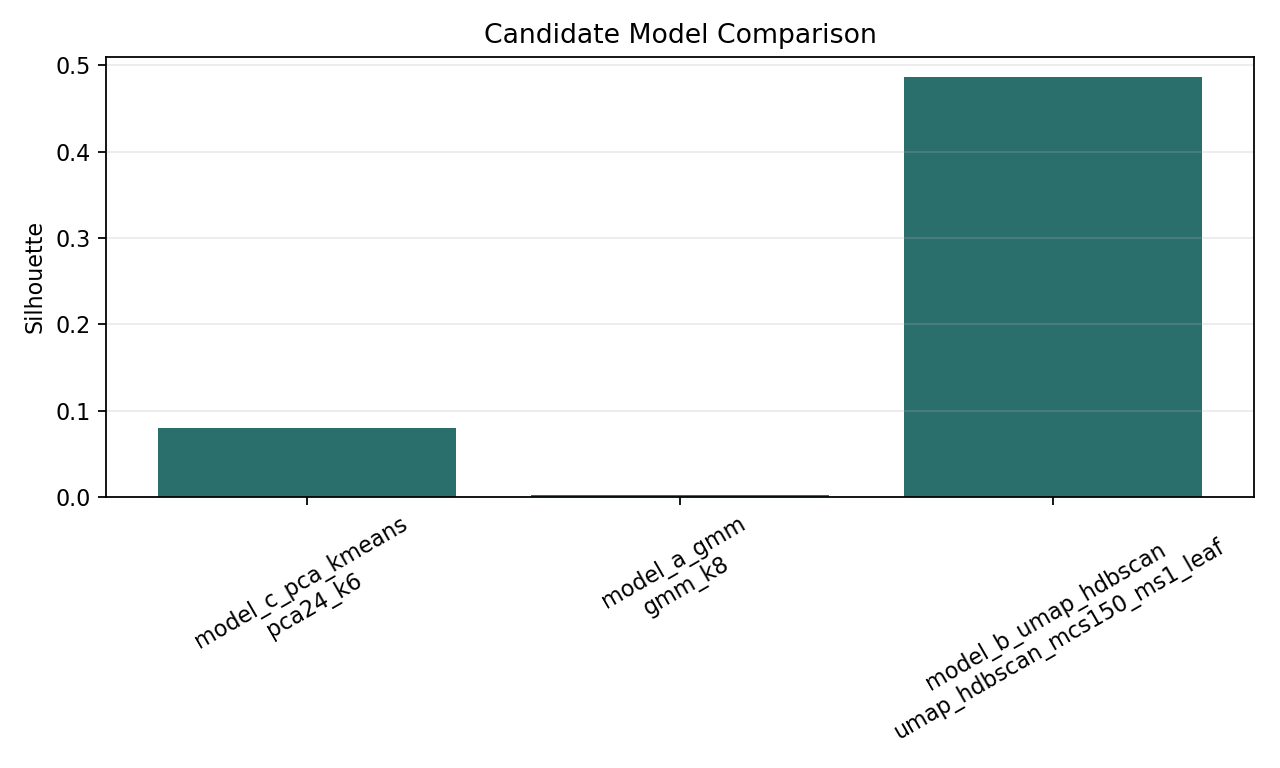

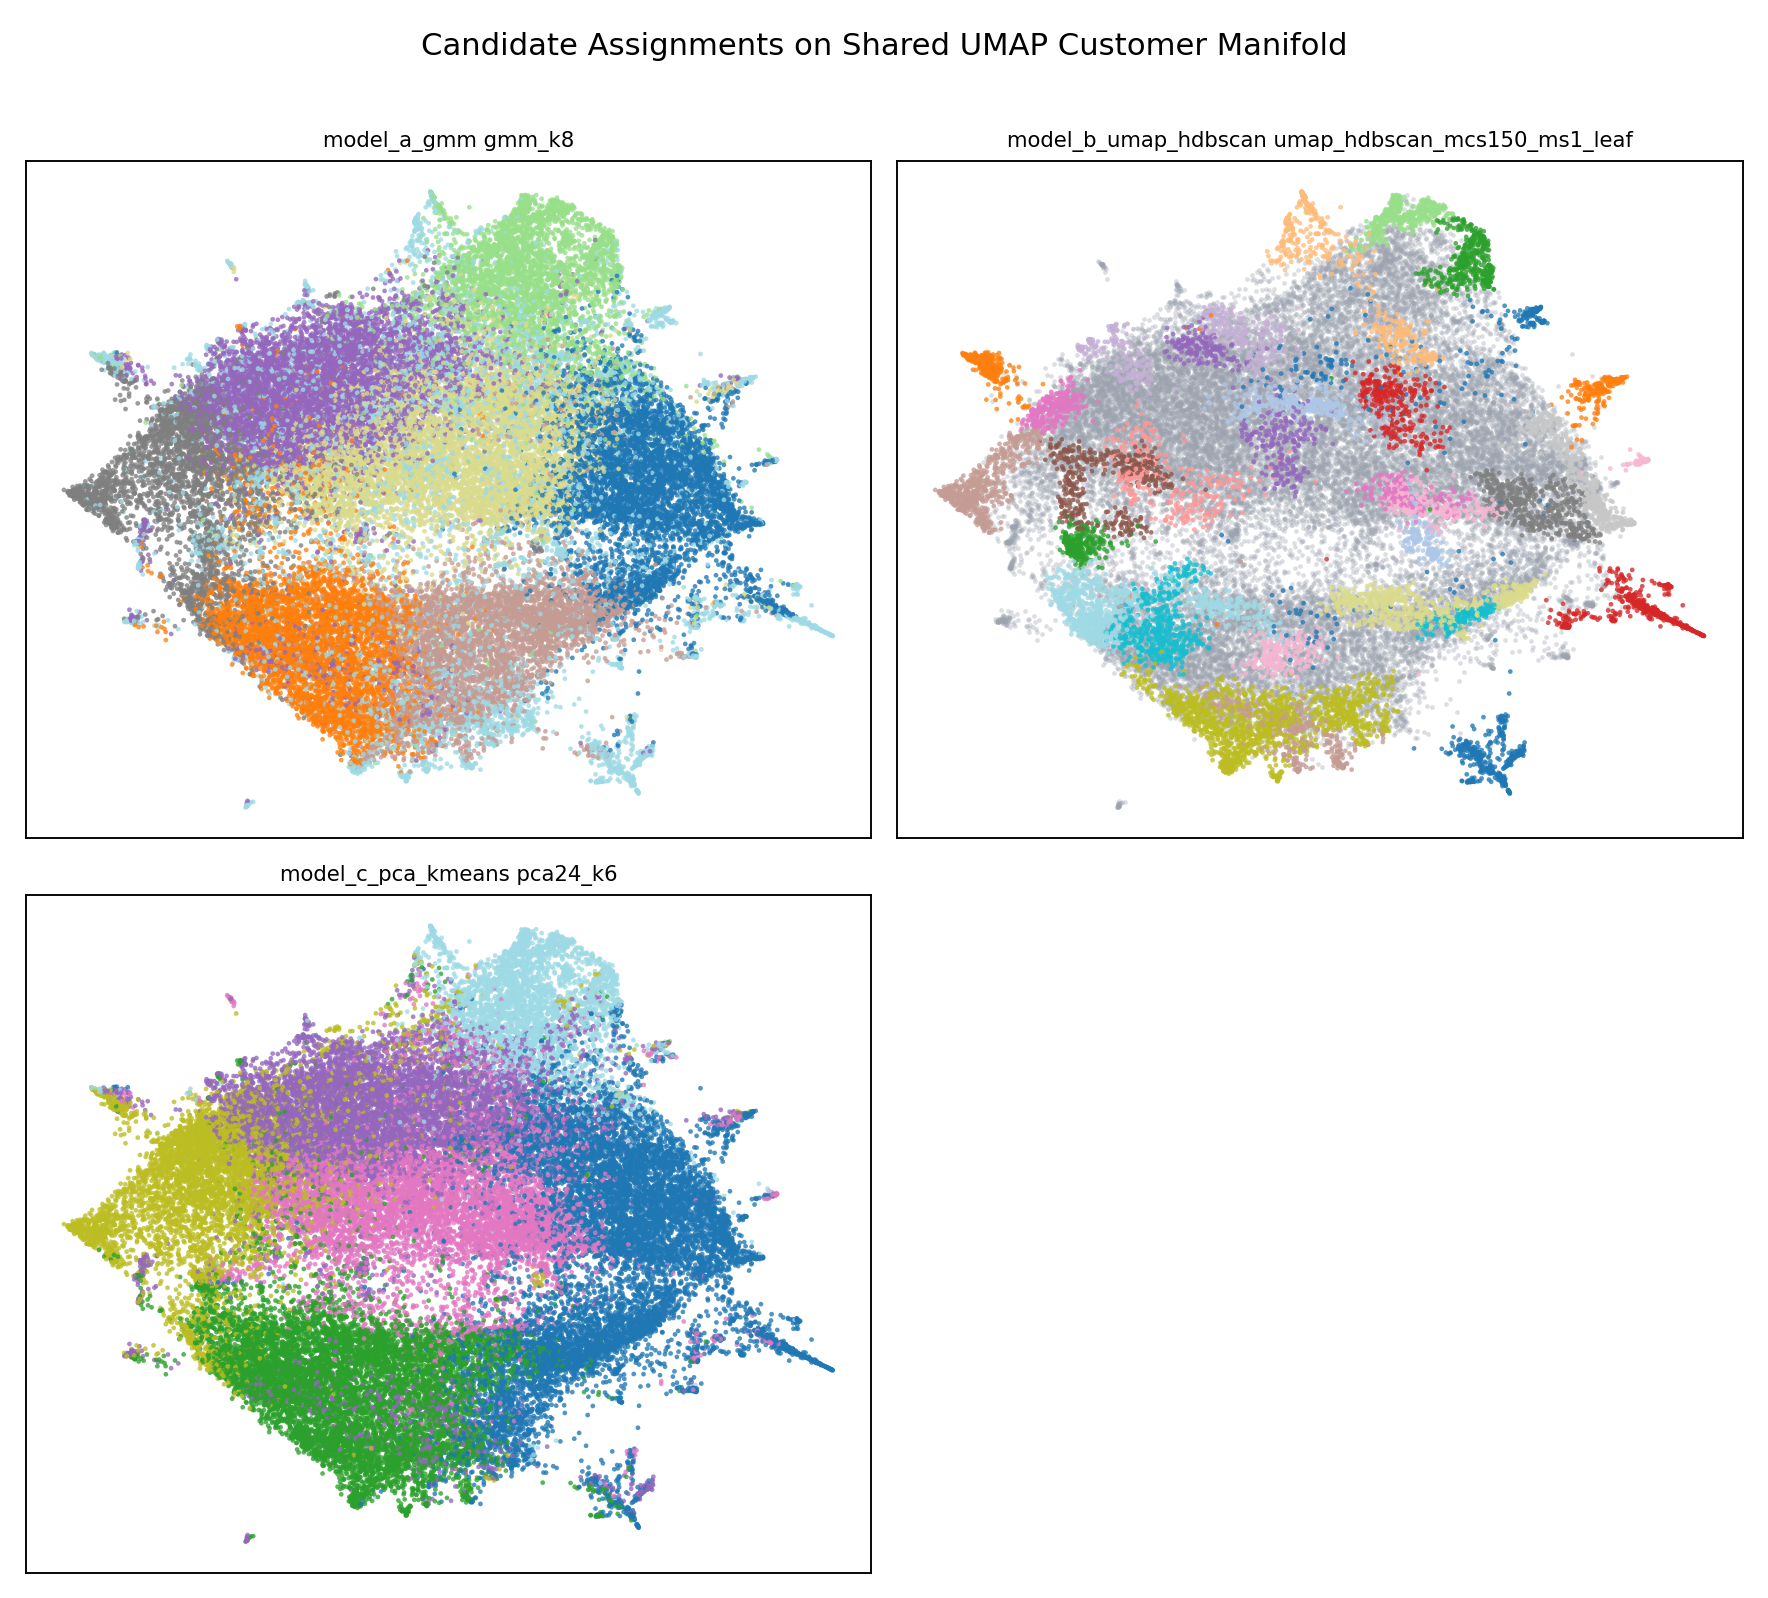

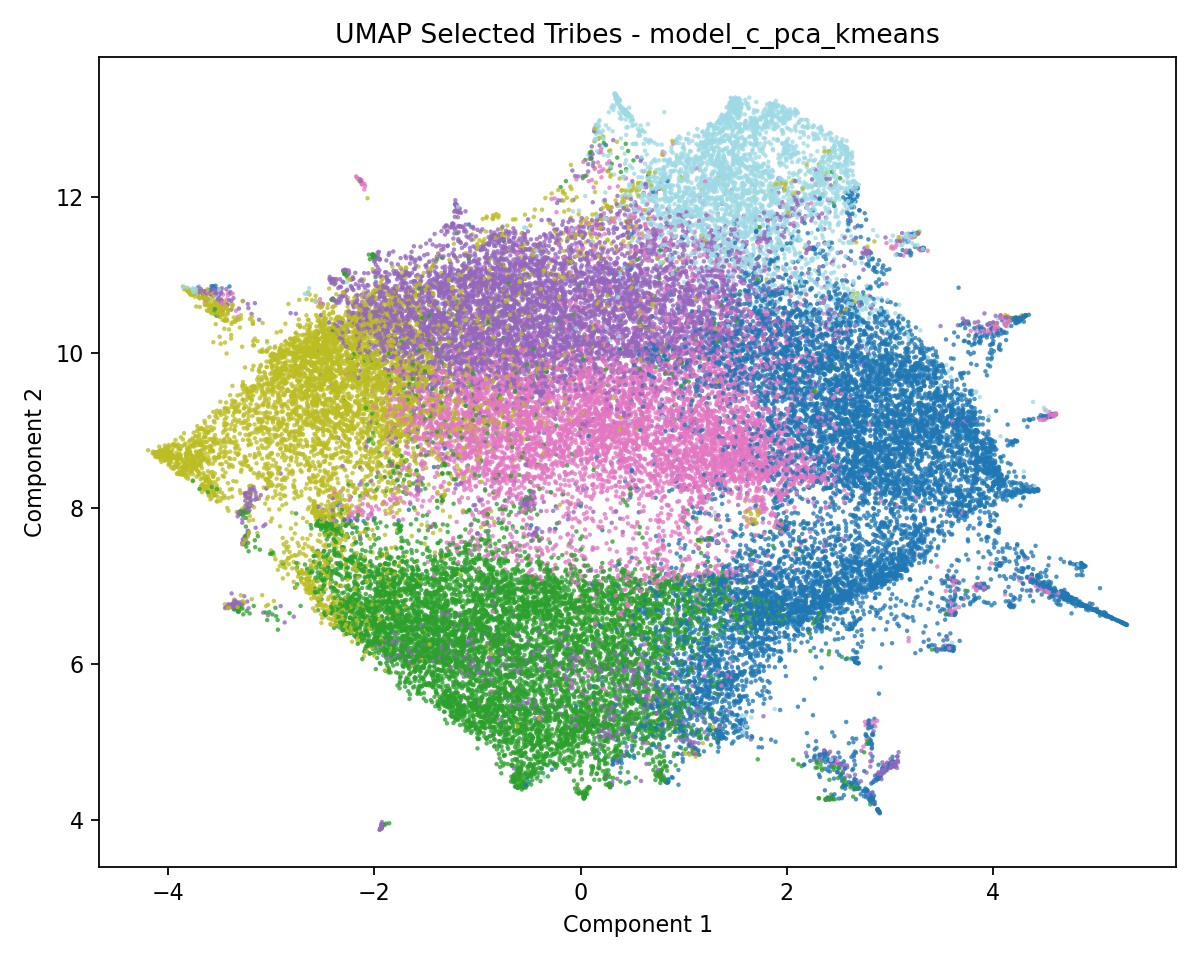

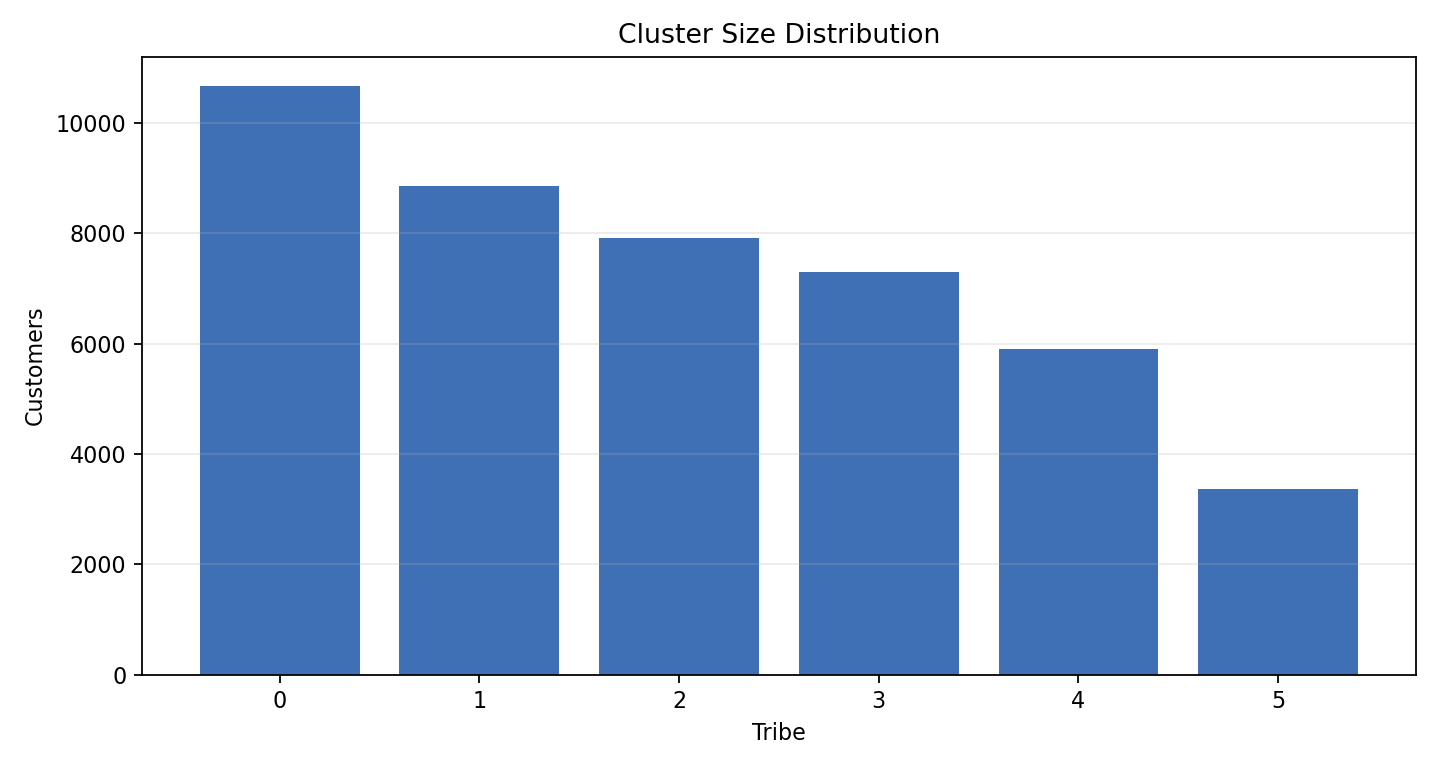


### Selected Solution

- Model: **model_c_pca_kmeans (pca24_k6)**
- Tribes: **6**
- Comparison table: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\model_comparison_dev.csv`
- Assignments: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\customer_tribe_assignments_dev.parquet`
- Tribe profiles: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\tribe_profiles_dev.csv`
- Decision log: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\reports\decision_log_dev.md`
- Figures folder: `C:\Users\vivim\OneDrive\Documentos\Capstone\carrefour_capstone\outputs\dev\figures`


In [18]:
from src.exports import (
    build_model_comparison,
    export_final_assignments,
    export_final_profiles,
    selected_model,
    write_decision_log,
)
from IPython.display import Image

from src.visualization import (
    build_2d_projection_figures,
    plot_candidate_umap_grid,
    plot_cluster_sizes,
    plot_model_comparison,
    plot_top_lifts,
)

comparison_path = build_model_comparison(
    model_suite["candidate_results"],
    profile_paths=profile_paths,
    cfg=CONFIG,
)
selected = selected_model(comparison_path)
selected_key = f"{selected['model_name']}::{selected['model_variant']}"
selected_assignment_path = model_suite["assignment_paths"][selected_key]
selected_profile_path = profile_paths[selected_key]

assignment_export = export_final_assignments(selected_assignment_path, cfg=CONFIG)
profile_export = export_final_profiles(selected_profile_path, cfg=CONFIG)
decision_log_path = write_decision_log(comparison_path, selected_profile_path, cfg=CONFIG)

figures = {
    "model_comparison": plot_model_comparison(comparison_path, cfg=CONFIG),
    "candidate_umap_grid": plot_candidate_umap_grid(
        feature_sets[selection_feature_set],
        model_suite["assignment_paths"],
        cfg=CONFIG,
    ),
    "cluster_sizes": plot_cluster_sizes(selected_assignment_path, cfg=CONFIG),
    "projection": build_2d_projection_figures(feature_sets[selection_feature_set], selected_assignment_path, cfg=CONFIG),
    "lift_plots": plot_top_lifts(selected_profile_path, cfg=CONFIG),
}

display(Image(filename=str(figures["model_comparison"])))
display(Image(filename=str(figures["candidate_umap_grid"])))
if "umap" in figures["projection"]:
    display(Image(filename=str(figures["projection"]["umap"])))
display(Image(filename=str(figures["cluster_sizes"])))

display(Markdown(f"""
### Selected Solution

- Model: **{selected['model_name']} ({selected['model_variant']})**
- Tribes: **{selected['cluster_count']}**
- Comparison table: `{comparison_path}`
- Assignments: `{assignment_export}`
- Tribe profiles: `{profile_export}`
- Decision log: `{decision_log_path}`
- Figures folder: `{CONFIG.figures}`
"""))

## Decision Log: Final Tribe Model Selection

This final section is generated after model evaluation and profiling. It records which model was selected, how many tribes were selected, whether that result agrees with the 10-15 tribe client hypothesis, why the selected model won, why alternatives were rejected, what evidence supports the recommendation, remaining limitations, and next production rollout steps.

In [12]:
from pathlib import Path

display(Markdown(Path(decision_log_path).read_text(encoding="utf-8")))

# Decision Log: Final Tribe Model Selection

Run mode: `dev`

## Selected Model

Selected model: **model_c_pca_kmeans (pca24_k6)**.
Selected tribe count: **6**.
This does not agree with the client hypothesis of 10-15 tribes.

The client expectation of 10-15 tribes was treated as a hypothesis rather than a constraint. The selected number of tribes was chosen based on empirical evaluation and interpretability, not because it matched the expected range.

## Why This Model Was Selected

The selected solution passed the configured quality gates and ranked first among eligible candidates using coverage-adjusted silhouette, Davies-Bouldin, balance, noise, and product-lift evidence. Its silhouette was 0.0797, Davies-Bouldin 2.3405, noise share 0.0000%, and cluster balance min share=7.63%, max share=24.25%, noise=0.00%.
Interpretability evidence: 6/6 tribes have strong product lift; 3/6 have sector lift.. Average maximum product lift was 6.0912 where available.

## Why Alternatives Were Not Selected

- model_a_gmm (gmm_k8) was not selected: rank 2, silhouette 0.0019, Davies-Bouldin 3.7054, noise 0.0000%, interpretability: 8/8 tribes have strong product lift; 6/8 have sector lift..
- model_b_umap_hdbscan (umap_hdbscan_mcs150_ms1_leaf) was not selected: rank 3, silhouette 0.4860, Davies-Bouldin 0.7680, noise 72.5374%, interpretability: 41/41 tribes have strong product lift; 26/41 have sector lift..

## Evidence Used

- Model comparison metrics: silhouette, Davies-Bouldin, Calinski-Harabasz where available.
- Cluster size balance: minimum and maximum population share, plus size dispersion.
- Interpretability: product lift, sector lift, and profile completeness.
- Assignment confidence for probabilistic GMM candidates.
- Noise share for HDBSCAN candidates.
- Stability evidence should be added from repeated seeds before production rollout if not already cached.

## Limitations

- Product descriptions and sector metadata are only as reliable as the prepared product master.
- Autoencoder and HDBSCAN candidates can be sensitive to scaling and sampling choices.
- The current decision log reflects the artifacts available in this run; production should rerun with the full prepared data.

## Recommended Next Steps

- Review top lifted products and sectors with Carrefour category experts.
- Rerun the selected model across multiple random seeds and compare tribe stability.
- Validate tribe actionability through campaign, assortment, and promo use cases.
- Run the same notebook in production mode after dev evidence is approved.
